## Disciplina VIS101: Fundamentos em Visão Computacional

### Anotações com Supervision

No notebook anterior, retângulos, círculos e textos foram desenhados um a um com o OpenCV: coordenadas à mão, cor à mão, espessura à mão. Funciona, mas não escala. Quando um detector encontra dezenas de objetos por quadro, ninguém escreve um `cv2.rectangle` por objeto.

A biblioteca **supervision**, da Roboflow, resolve exatamente essa camada: recebe as detecções de qualquer modelo e cuida do desenho com uma linha. Nesta aula ela é usada com um detector pronto, treinado no dataset COCO, sem nenhum treinamento da nossa parte.

In [22]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
from supervision.assets import download_assets, VideoAssets
from ultralytics import YOLO
import shutil

print(sv.__version__)

0.29.1


### Um detector pronto

O modelo **YOLO26 nano** já sai de fábrica reconhecendo 80 categorias de objetos do dia a dia (pessoa, carro, cachorro, celular, etc).
Podemos saber mais a respeito [aqui.](https://docs.ultralytics.com/datasets/detect/coco#coco-pretrained-models)

In [23]:
model = YOLO('../models/yolo26n.pt',) 

img = cv2.imread('../images/rua.webp')

if img is None:
    print(f"❌ ERRO: O OpenCV não encontrou a imagem em: {caminho_imagem}")
else:
    print("✅ Imagem carregada! Rodando detecção...")
    # Roda a inferência
    results = model(img, verbose=False)[0]
    print(f"Sucesso! O modelo encontrou {len(results.boxes)} objetos na imagem.")

results = model(img, verbose=False)[0]

✅ Imagem carregada! Rodando detecção...
Sucesso! O modelo encontrou 14 objetos na imagem.


### O objeto Detections

A ponte entre o detector e o desenho é o `sv.Detections`. Ele guarda, para cada objeto encontrado, a caixa (`xyxy`), a confiança e a classe, num formato único que a supervision entende independente do modelo de origem.

In [24]:
detections = sv.Detections.from_ultralytics(results)
detections

Detections(xyxy=array([[     561.21,      344.77,      717.44,      824.25],
       [     11.585,      339.06,      134.86,       661.3],
       [     739.46,      387.56,      838.11,      701.92],
       [     946.79,      367.49,      999.58,      560.57],
       [     124.57,      337.28,      167.68,      524.06],
       [     679.78,      685.77,      860.12,      833.85],
       [     805.06,       370.2,      861.06,       555.5],
       [     518.82,      355.22,       559.3,      471.63],
       [     236.21,      415.27,      276.68,      528.76],
       [     860.76,      381.52,      930.82,      560.92],
       [     370.63,      345.71,       423.9,      506.62],
       [      191.3,      350.79,      236.12,      484.93],
       [     255.68,      351.79,      300.29,      484.04],
       [      681.1,      675.83,      904.88,       834.6]], dtype=float32), mask=None, confidence=array([    0.88848,     0.85824,     0.73634,     0.72572,     0.63029,     0.61537,      0

In [25]:
print(detections.xyxy)
print(detections.confidence)
print(detections['class_name'])

[[     561.21      344.77      717.44      824.25]
 [     11.585      339.06      134.86       661.3]
 [     739.46      387.56      838.11      701.92]
 [     946.79      367.49      999.58      560.57]
 [     124.57      337.28      167.68      524.06]
 [     679.78      685.77      860.12      833.85]
 [     805.06       370.2      861.06       555.5]
 [     518.82      355.22       559.3      471.63]
 [     236.21      415.27      276.68      528.76]
 [     860.76      381.52      930.82      560.92]
 [     370.63      345.71       423.9      506.62]
 [      191.3      350.79      236.12      484.93]
 [     255.68      351.79      300.29      484.04]
 [      681.1      675.83      904.88       834.6]]
[    0.88848     0.85824     0.73634     0.72572     0.63029     0.61537      0.6112     0.56143     0.56038     0.55583     0.52426     0.42207     0.39283     0.27665]
['person' 'person' 'person' 'person' 'person' 'dog' 'person' 'person' 'person' 'person' 'person' 'person' 'person' 

Repare no formato da caixa: os mesmos quatro números `(x1, y1, x2, y2)` que foram passados manualmente ao `cv2.rectangle` no notebook anterior. A diferença é que agora quem os produz é o detector.

### Desenhando as caixas

O `sv.BoxAnnotator` desenha todas as caixas de uma vez. Um detalhe de versão importante: em tutoriais antigos o `BoxAnnotator` também escrevia o rótulo, mas na API atual ele desenha **apenas a caixa**; o texto é responsabilidade de outro annotator.

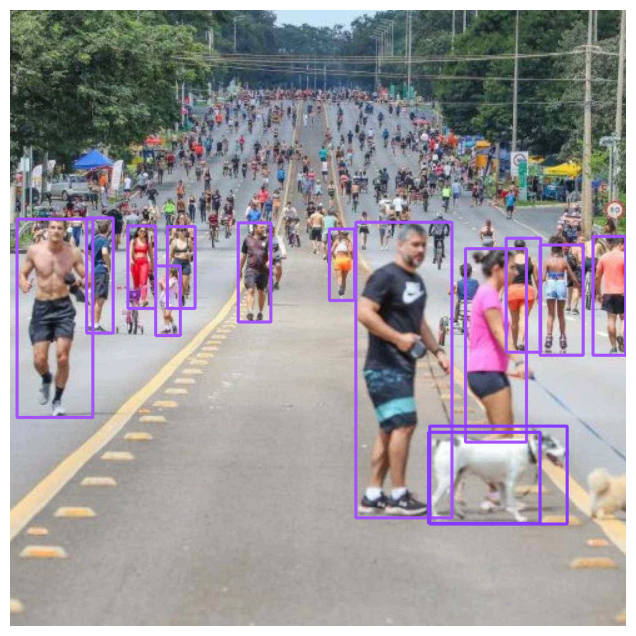

In [26]:
box_annotator = sv.BoxAnnotator(thickness=3)

anotada = box_annotator.annotate(scene=img.copy(), detections=detections)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(anotada, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### Rótulos com classe e confiança

O `sv.LabelAnnotator` escreve o texto de cada detecção. Os rótulos são montados com uma list comprehension sobre a classe e a confiança, o mesmo papel do `cv2.putText` de antes.

In [27]:
labels = [
    f'{classe} {conf:.2f}'
    for classe, conf in zip(detections['class_name'], detections.confidence)
]
print(labels)

['person 0.89', 'person 0.86', 'person 0.74', 'person 0.73', 'person 0.63', 'dog 0.62', 'person 0.61', 'person 0.56', 'person 0.56', 'person 0.56', 'person 0.52', 'person 0.42', 'person 0.39', 'dog 0.28']


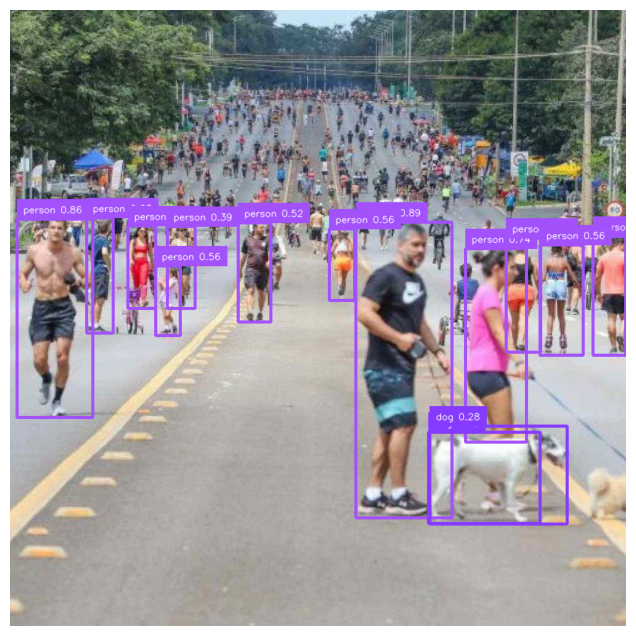

In [28]:
# Instancia o renderizador de texto, abstraindo as configurações visuais do OpenCV (fonte, cor e fundo)
label_annotator = sv.LabelAnnotator()

# Aplica as etiquetas na imagem unindo a tela (scene), as coordenadas físicas (detections) e os textos (labels)
anotada = label_annotator.annotate(scene=anotada, detections=detections, labels=labels)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(anotada, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### Trocando o estilo sem tocar na detecção

A separação entre detecção e desenho rende de graça uma família inteira de estilos: caixas arredondadas, cantos, círculos, blur de privacidade. A detecção é a mesma; só o annotator muda.

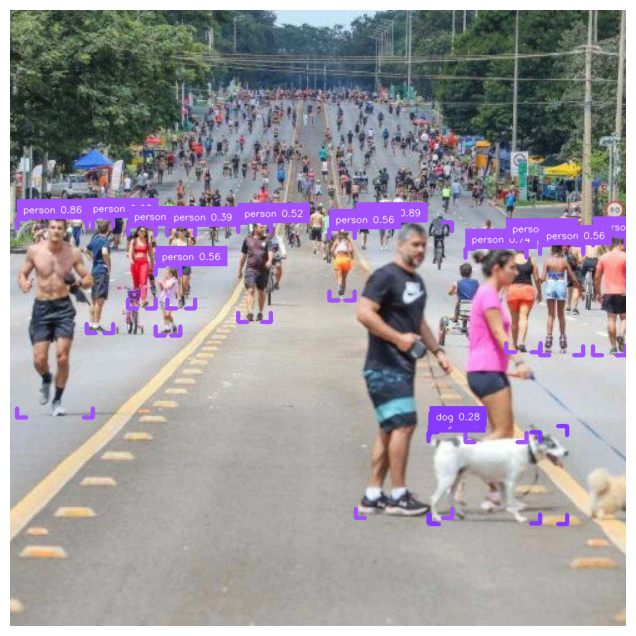

In [29]:
corner_annotator = sv.BoxCornerAnnotator(thickness=6)

estilizada = corner_annotator.annotate(scene=img.copy(), detections=detections)
estilizada = label_annotator.annotate(scene=estilizada, detections=detections, labels=labels)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(estilizada, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### De imagem para vídeo

Vídeo é uma sequência de imagens, e a supervision traz vídeos de exemplo prontos no módulo assets.

In [30]:
pasta_destino = '../videos/'
os.makedirs(pasta_destino, exist_ok=True) # Cria a pasta caso não exista

nome_arquivo = VideoAssets.PEOPLE_WALKING.value
caminho = os.path.join(pasta_destino, nome_arquivo)

if not os.path.exists(caminho):
    print("Baixando o vídeo...")
    arquivo_temporario = download_assets(VideoAssets.PEOPLE_WALKING)
    shutil.move(arquivo_temporario, caminho)
else:
    print("👍 O vídeo já estava baixado!")

print(f"✅ Vídeo pronto para uso no caminho: {caminho}")

👍 O vídeo já estava baixado!
✅ Vídeo pronto para uso no caminho: ../videos/people-walking.mp4


### Rastreamento: dando identidade às detecções

Detectar quadro a quadro não diz que o pedestre do quadro 10 é o mesmo do quadro 11. Quem costura as detecções no tempo é o **tracker**. O `sv.ByteTrack` atribui um `tracker_id` a cada objeto, e o `sv.TraceAnnotator` desenha o rastro do caminho percorrido.

In [ ]:
tracker = sv.ByteTrack()              # Rastreador: dá um ID único e acompanha o movimento entre os frames
trace_annotator = sv.TraceAnnotator() # Visual: desenha a linha (rastro) do caminho percorrido
box_video = sv.BoxAnnotator()         # Visual: desenha a caixa retangular ao redor da detecção
label_video = sv.LabelAnnotator()     # Visual: escreve a etiqueta de texto (ID, classe, etc.) na caixa

In [32]:
def callback(frame, indice):
    results = model(frame, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = tracker.update_with_detections(detections)
    labels = [f'#{t}' for t in detections.tracker_id]
    anotado = box_video.annotate(frame.copy(), detections=detections)
    anotado = trace_annotator.annotate(anotado, detections=detections)
    return label_video.annotate(anotado, detections=detections, labels=labels)

A próxima célula roda o detector em todos os quadros do vídeo.

In [33]:
sv.process_video(
    source_path=caminho,
    target_path='../output/people-walking-anotado.mp4',
    callback=callback,
)

O `process_video` percorre o vídeo inteiro aplicando o `callback` em cada quadro e grava o resultado. Um quadro do meio serve de conferência:

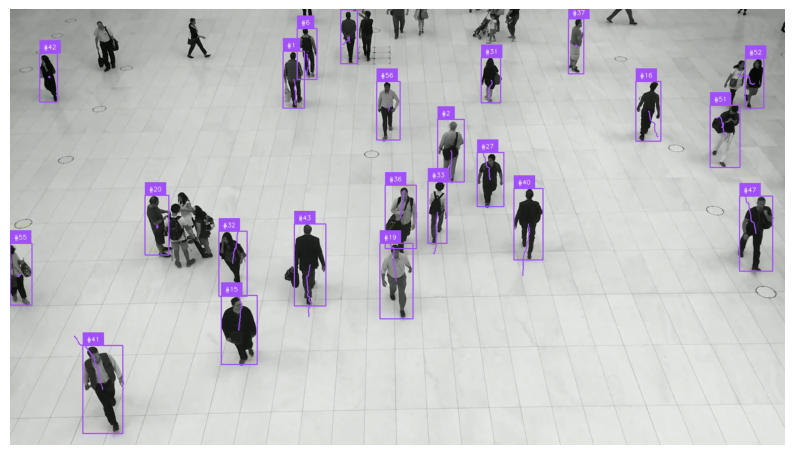

In [34]:
cap = cv2.VideoCapture('../output/people-walking-anotado.mp4')
meio = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, meio)
ok, frame = cap.read()
cap.release()
assert ok

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Aqui conseguimos visualizar o vídeo:

In [35]:
cap = cv2.VideoCapture('../output/people-walking-anotado.mp4')

# Verifica se o vídeo foi aberto corretamente
if not cap.isOpened():
    print("Erro ao abrir o vídeo.")

while cap.isOpened():
    ok, frame = cap.read()
    
    # Se não leu o frame (chegou ao fim do vídeo), sai do loop
    if not ok:
        break
        
    # Mostra o frame em uma janela chamada 'Video Anotado'
    cv2.imshow('Video Anotado', frame)
    
    # Espera 25 milissegundos e verifica se a tecla 'q' foi pressionada para sair
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

# Libera o vídeo e fecha as janelas
cap.release()
cv2.destroyAllWindows()

### Mapa de calor e marcadores circulares (Heatmap & Ellipse)

Nesta célula, mudamos a forma de visualizar o movimento no vídeo. Em vez de usar as caixas retangulares clássicas e as linhas de trajeto, vamos aplicar duas ferramentas visuais diferentes: um **Mapa de Calor** para analisar a densidade do fluxo e **Círculos na base** das pessoas para uma marcação mais limpa.

### 1. O mapa de calor (Heatmap)
O Mapa de Calor (geralmente criado com o `sv.HeatMapAnnotator`) serve para nos mostrar *quais áreas* do cenário são mais utilizadas ao longo do tempo.

* **Como funciona:** O algoritmo guarda a posição de cada pessoa a cada frame. Toda vez que alguém passa por um local, essa área do chão "esquenta".
* **Lendo as cores:** 
  * Áreas transparentes ou em **azul/verde** representam locais onde poucas ou nenhuma pessoa passou.
  * Áreas em **amarelo, laranja e vermelho** indicam alto tráfego (locais onde muitas pessoas andam ou costumam parar).
* **Aplicações reais:** Isso é extremamente útil no mundo real para arquitetura urbana, design de lojas (para saber quais corredores recebem mais clientes) e análise de segurança em eventos.

### 2. O círculo sob as pessoas (Ellipse Annotator)
No lugar da caixa (Bounding Box) que cobre o corpo inteiro, usamos uma elipse/círculo (como o `sv.EllipseAnnotator`) que fica ancorada nos pés da pessoa.

* **A Vantagem visual:** Substituir as caixas por círculos no chão deixa o vídeo **muito menos poluído**. Em cenas com multidões, várias caixas sobrepostas formam uma bagunça visual. O círculo resolve isso.
* **Perspectiva:** Como o círculo é desenhado na base da detecção (onde a pessoa toca o chão), ele cria uma sensação melhor de profundidade (um efeito 3D), parecendo a "sombra" ou a marcação exata da pisada do pedestre no ambiente.

### Como o sistema monta esse visual?

Para cada frame do vídeo, o seu código faz o seguinte:

1. **Detecta e rastreia:** O modelo encontra as pessoas e acompanha quem é quem (Tracking).
2. **"Esquenta" o chão:** O modelo pega a coordenada inferior da pessoa (os pés) e adiciona "calor" àquela região na memória do mapa.
3. **Desenha os marcadores:** O círculo é desenhado ao redor do ponto onde a pessoa está pisando.
4. **Combinação final:** O frame é gerado misturando as cores translúcidas do mapa de calor no chão com os círculos acompanhando as pessoas em movimento.

In [ ]:
# Carrega o modelo de detecção
model = YOLO('../models/yolo26n.pt',)

# Inicialização (fora da função callback)
# Isso é super importante para o mapa de calor e o rastreador lembrarem do passado!
tracker = sv.ByteTrack()
ellipse_annotator = sv.EllipseAnnotator()
heatmap_annotator = sv.HeatMapAnnotator()

# Definição da nova função de callback
def process_frame(frame: np.ndarray, index: int) -> np.ndarray:
    # Roda o modelo no frame atual procurando apenas pessoas (classes=[0])
    results = model(frame, classes=[0], verbose=False)[0]
    
    # Converte os resultados para o formato do Supervision
    detections = sv.Detections.from_ultralytics(results)
    
    # Atualiza o rastreador (associa um ID para cada pessoa)
    detections = tracker.update_with_detections(detections)
    
    # Cria uma cópia do frame para não alterar o original diretamente
    annotated_frame = frame.copy()
    
    # Etapa visual: Desenha o mapa de calor no chão
    annotated_frame = heatmap_annotator.annotate(
        scene=annotated_frame,
        detections=detections
    )
    
    # Etapa visual: Desenha as elipses (círculos) na base das pessoas
    annotated_frame = ellipse_annotator.annotate(
        scene=annotated_frame,
        detections=detections
    )
    
    return annotated_frame

# Processamento do vídeo
caminho_entrada = caminho
caminho_saida = '../output/people-walking-heatmap.mp4'

print("Iniciando o processamento do vídeo. Isso pode levar alguns minutos...")

sv.process_video(
    source_path=caminho_entrada,
    target_path=caminho_saida,
    callback=process_frame
)

print(f"Pronto! Vídeo salvo como: {caminho_saida}")

Iniciando o processamento do vídeo. Isso pode levar alguns minutos...
Pronto! Vídeo salvo como: ../output/people-walking-heatmap.mp4


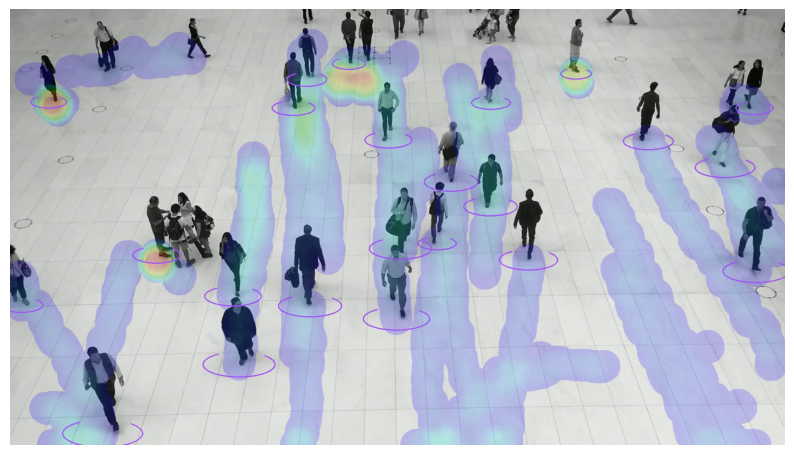

In [ ]:
cap = cv2.VideoCapture('../output/people-walking-heatmap.mp4')

# Calcula qual é o frame exato do meio do vídeo
meio = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2

# Pula direto para esse frame
cap.set(cv2.CAP_PROP_POS_FRAMES, meio)

# Lê a imagem e fecha o arquivo
ok, frame = cap.read()
cap.release()

# Verifica se deu tudo certo
assert ok, "Erro ao ler o frame."

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

_____________
### Síntese

A gramática visual é a mesma do notebook anterior: caixa, rótulo, traço. O que mudou foi quem faz o trabalho. Com o OpenCV cada marca foi desenhada à mão; com a supervision, o detector produz as coordenadas e os annotators desenham tudo de uma vez, em imagem ou em vídeo, com rastreamento por identidade. Essa separação entre detectar e desenhar é o padrão dos sistemas reais de visão computacional.